In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import fiona

%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Section One: computing "gerrymandering scores" and building the data frame

In [2]:
# congressional district boundaries cong116 data set: https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
dists_map = gpd.read_file("data_2018/cb_2018_us_cd116_500k.shp", engine="fiona")

# congressional district election data set: https://github.com/PrincetonUniversity/gerrymandertests/tree/master/election_data
dists_demo = gpd.read_file("data_2018/congressional_election_results_post1948.csv", engine="fiona")

In [3]:
# remove data from years besides 2018
dists_demo = dists_demo[dists_demo["Year"] == "2018"]
dists_demo["codes"] = dists_demo["State"] + dists_demo["District"]
dists_demo = dists_demo.drop(columns = ["State", "District"])

In [4]:
# functions to compute and plot convex hull
# input state, district number as strings
def comp_hull(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    return(hull)

def plot_hull(state, d):
    hull = comp_hull(state, d)
    hull.plot(figsize = (20, 20))

# compute region of convex hull outside of the district
def hull_overlap(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]
    hull = dist.convex_hull
    overlap = hull.difference(dist)
    return(overlap)

def plot_overlap(state, d):
    overlap = hull_overlap(state, d)
    overlap.plot(figsize = (20, 20))

# compute region of convex hull outside of district but within state lines
def hull_intersection(state, d):
    state_plot = dists_map[dists_map["State"] == state]
    hull = hull_overlap(state, d)
    hull_df = gpd.GeoDataFrame(geometry = hull)
    intersection = gpd.overlay(state_plot, hull_df, how="intersection", keep_geom_type = True)
    return(intersection)

def plot_intersection(state, d):
    intersection = hull_intersection(state, d)
    intersection.plot(figsize = (20, 20))

# compute area of convex hull outside of district but within state lines
def hull_area(state, d):
    hull_pts = hull_intersection(state, d)
    hull = sum(hull_pts.geometry.to_crs("epsg:32633").area)
    return(hull)

# compute ratio of area of convex hull outside of district but within state lines to area of district
# idea: higher ratio implies that the district is less convex
# this function is unnecessary as all values are stored in df
def hull_ratio(state, d):
    dist = dists_map[(dists_map["State"] == state) & (dists_map["District"] == d)]["Area"]
    hull = hull_area(state, d)
    ratio = hull / dist
    return(ratio)

In [5]:
# fips to state abbreviations
fips_to_state = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA",
    "08": "CO", "09": "CT", "10": "DE", "12": "FL", "13": "GA", 
    "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", 
    "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", 
    "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", 
    "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", 
    "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", 
    "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", 
    "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", 
    "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

dists_map["State"] = dists_map["STATEFP"].map(fips_to_state)
dists_map["District"] = list(map(lambda s: s.lstrip("0"), dists_map["CD116FP"]))
dists_map["District"] = dists_map["District"].apply(lambda x: "1" if x == "" else x)

# remove territories
dists_map = dists_map.dropna()

In [6]:
# compute all hull areas
hull_areas = []
for i in range(0, len(dists_map)):
    state = dists_map["State"].iloc[i]
    d = dists_map["District"].iloc[i]
    hull = hull_area(state, d)
    hull_areas.append(hull)

# compute total percentage democrats for each state
dem_percs = []
for i in range(0, len(dists_map)):
    state = dists_map["State"].iloc[i]
    d = dists_map["District"].iloc[i]
    dem_num = sum(dists[dists["State"] == state]["Dem Votes"].astype(float))
    rep_num = sum(dists[dists["State"] == state]["GOP Votes"].astype(float))
    dem_perc = dem_num / (dem_num + rep_num)
    dem_percs.append(dem_perc)

In [ ]:
# compute average

In [66]:
dists_map["geom_crs"] = dists_map["geometry"].geometry.to_crs("epsg:32633")
dists_map["Area"] = dists_map["geom_crs"].area
dists_map["hull_area"] = hull_areas
dists_map["Ratio"] = dists_map["hull_area"] / dists_map["Area"]
dists_map["codes"] = dists_map["State"] + dists_map["District"]
dists_map["dem_percs"] = dem_percs

In [67]:
# merge dfs on state and district
dists = pd.merge(dists_demo, dists_map, on = "codes", how = "outer")
dists_geo = gpd.GeoDataFrame(dists)
dists_geo["D Voteshare"] = dists_geo["D Voteshare"].astype(float)
dists_geo["dem_percs"] = dists_geo["dem_percs"].astype(float)

In [64]:
sum(dem_percs) / len(dem_percs)

0.5445312358884005

In [46]:
sum(dists[dists["State"] == "IL"]["Dem Votes"].astype(float)) / (sum(dists[dists["State"] == "IL"]["Dem Votes"].astype(float)) + sum(dists[dists["State"] == "IL"]["GOP Votes"].astype(float)))

0.6111584048631324

In [69]:
dists.sort_values(by = "Ratio").tail(4)

,Year,Dem Votes,GOP Votes,D Voteshare,Incumbent,Party,codes,STATEFP,CD116FP,AFFGEOID,...,ALAND,AWATER,geometry,State,District,geom_crs,Area,hull_area,Ratio,dem_percs
203,2018,214334.0,45899.0,0.8236234451433907,D,D,MI14,26,14,5001600US2614,...,480339355,97940449,"POLYGON ((-83.43929 42.56014, -83.43626 42.562...",MI,14,"POLYGON ((-5406712.17 11007935.08, -5406398.20...",1.067566e+09,1.585160e+09,1.484836,0.539909
174,2018,190182.0,0.0,1.0,D,D,LA2,22,02,5001600US2202,...,3285174126,522407749,"POLYGON ((-91.32548 30.34681, -91.31954 30.343...",LA,2,"POLYGON ((-7036542.661 12841428.217, -7037547....",1.239493e+10,1.954778e+10,1.577079,0.398290
389,2018,138278.0,50553.0,0.7322844236380679,D,D,TX35,48,35,5001600US4835,...,1538273012,19151538,"POLYGON ((-98.54734 29.44272, -98.5437 29.4423...",TX,35,"POLYGON ((-6478012.226 13915657.866, -6478450....",4.287454e+09,7.461464e+09,1.740302,0.482311
190,2018,202407.0,82774.0,0.7097492469694685,D,D,MD3,24,03,5001600US2403,...,788544340,252344417,"POLYGON ((-77.15601 39.26353, -77.15607 39.264...",MD,3,"POLYGON ((-6064962.191 10290704.561, -6064754....",2.056357e+09,4.642475e+09,2.257621,0.669242


In [14]:
dists[["State", "District","Ratio"]].sort_values(by = "Ratio", ascending = False).head(10)

,State,District,Ratio
190,MD,3,2.257621
389,TX,35,1.740302
174,LA,2,1.577079
203,MI,14,1.484836
148,IL,4,1.383113
372,TX,2,1.382615
387,TX,33,1.325900
272,NY,10,1.297356
295,NY,7,1.285118
189,MD,2,1.282162


### Section two: analysing the data

In [ ]:
dists_map[(dists_map["State"] == "MI") & (dists_map["District"] == "14")].plot(figsize = (20, 20))

In [ ]:
plot_hull("TX", "16")

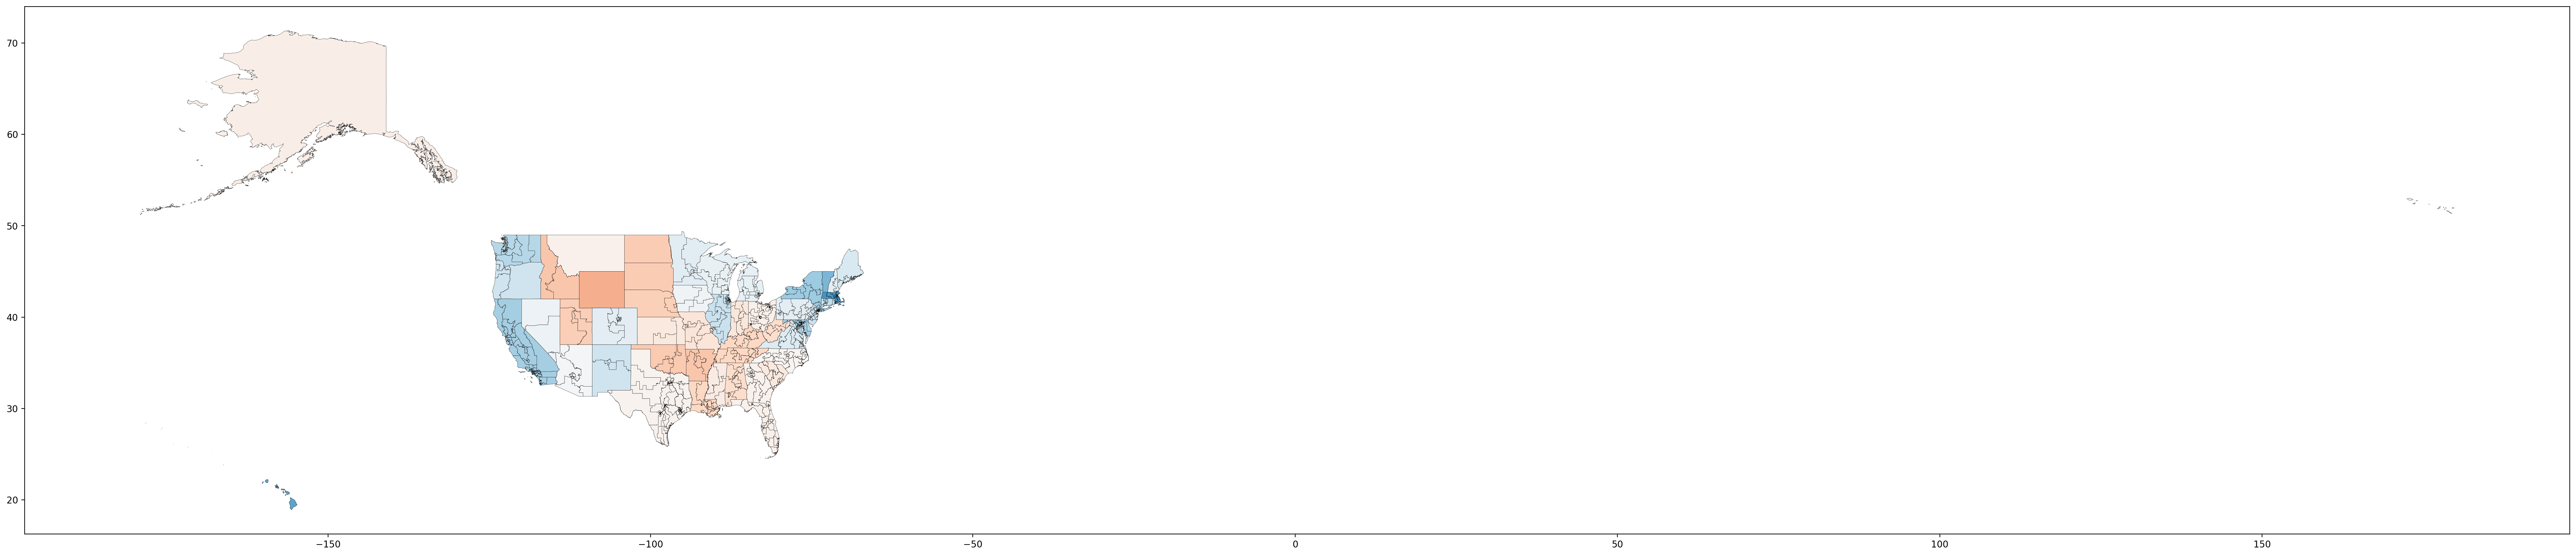

In [70]:
# plot full image with coloring
dists_map.plot(
    column="dem_percs",
    #legend=True,
    figsize=(50, 50),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

In [ ]:
# graph entire us colored with democratic voter percentages
dists_geo.plot(
    column="D Voteshare",
    #legend=True,
    figsize=(100, 100),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0.30,
    vmax = 0.70
);

# graph entire us colored with convexity ratios
dists_map.plot(
    column="Ratio",
    #legend=True,
    figsize=(100, 100),
    edgecolor="black",
    linewidth=0.2,
    cmap = "RdBu",
    vmin = 0,
    vmax = 1
);

<Axes: xlabel='D Voteshare', ylabel='Ratio'>

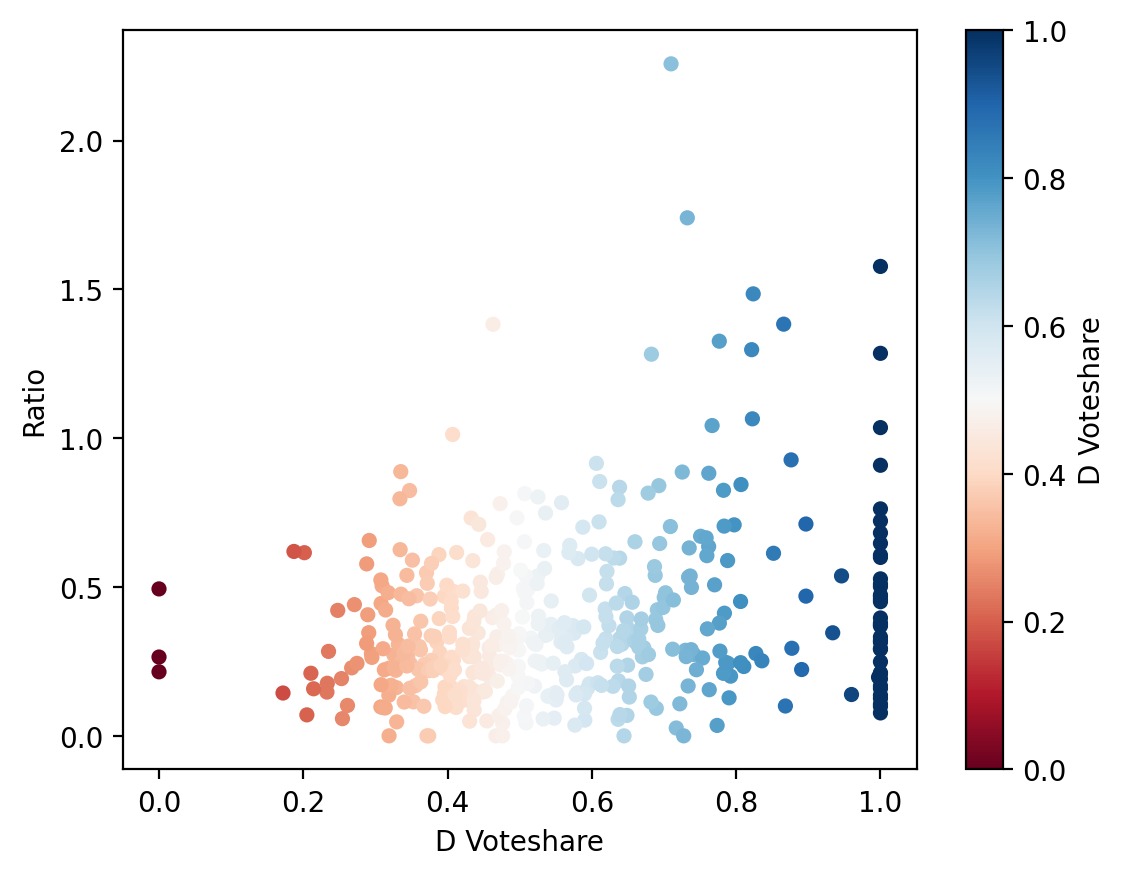

In [136]:
# compare political alignments and convexity ratios
dists_geo.plot.scatter(x = "D Voteshare", y = "Ratio", c = "D Voteshare", cmap = "RdBu")

<Axes: xlabel='D Voteshare', ylabel='Ratio'>

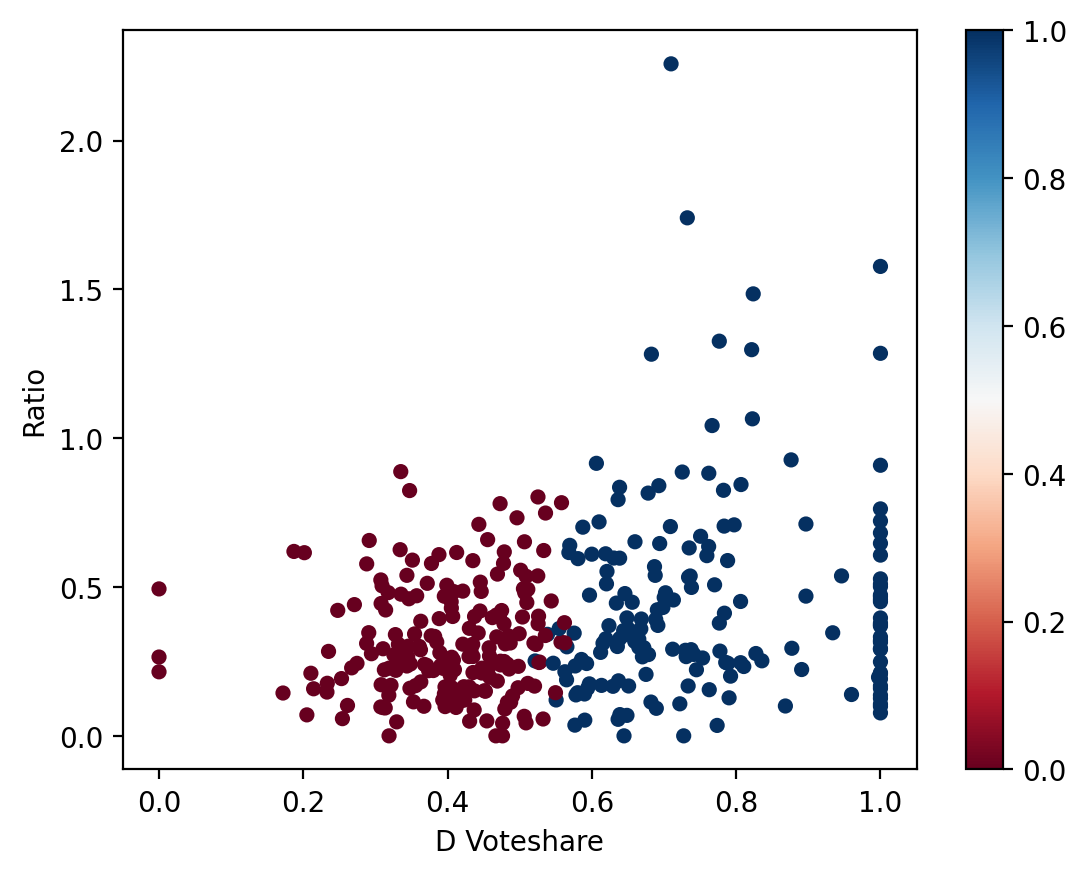

In [40]:
# color scatter plot based on incumbent party
# idea: color graph depending on agreements
# DR = democrat elected in a republican district
# RD = republican elected in a democratic district
color_map = {"D": 1, "R": 0}
colors = dists_geo["Incumbent"].map(color_map)
dists_geo.plot.scatter(x = "D Voteshare", 
                       y = "Ratio", 
                       c = colors, 
                       cmap = "RdBu",
                       vmin = 0,
                       vmax = 1)

#### Subsection a: linear regression

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

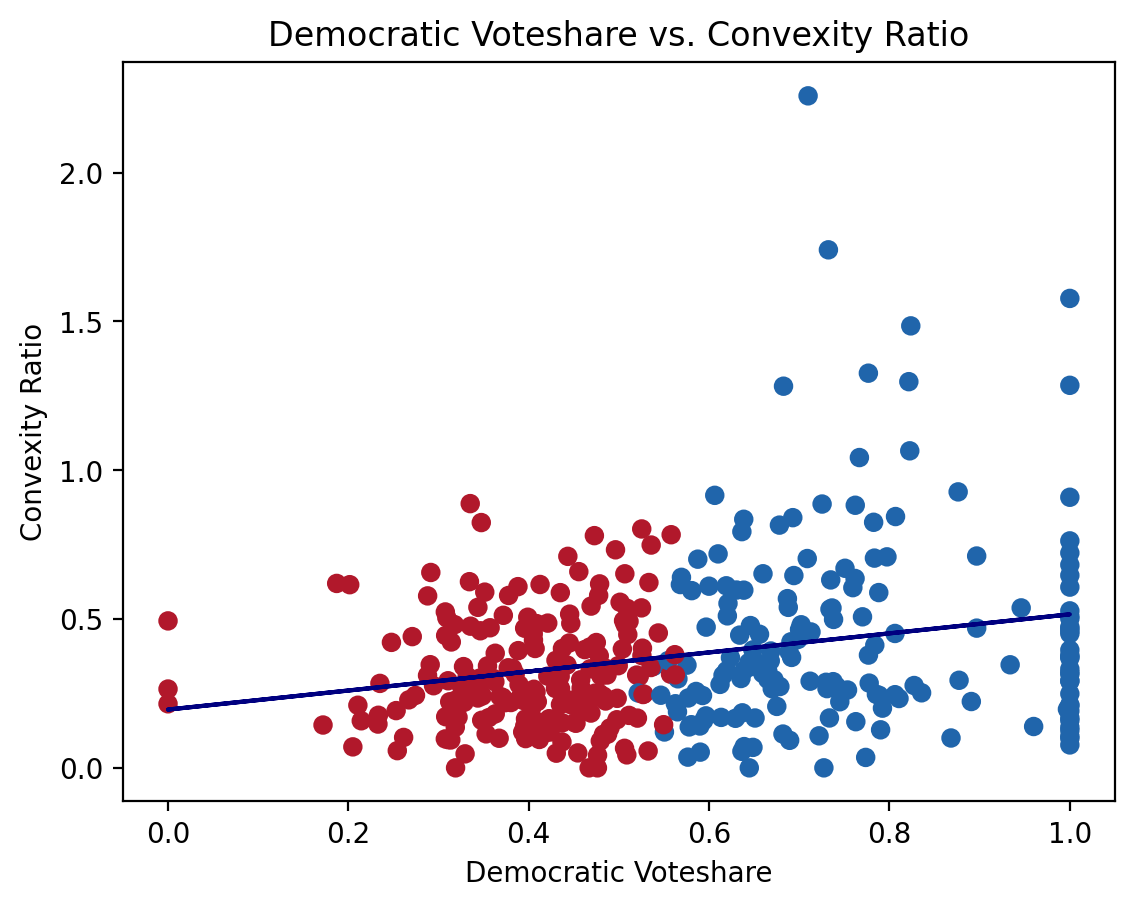

In [25]:
# single regression line for all data
color_map = {"D": 0.9, "R": 0.1}
colors = dists_geo["Incumbent"].map(color_map)

x = dists_geo[["D Voteshare"]]
y = dists_geo[["Ratio"]]

regressor = LinearRegression()
regressor.fit(x, y)

plt.scatter(x, 
            y, 
            c = colors, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x, regressor.predict(x), color = 'navy')
plt.title("Democratic Voteshare vs. Convexity Ratio")
plt.xlabel("Democratic Voteshare")
plt.ylabel("Convexity Ratio")
plt.show()

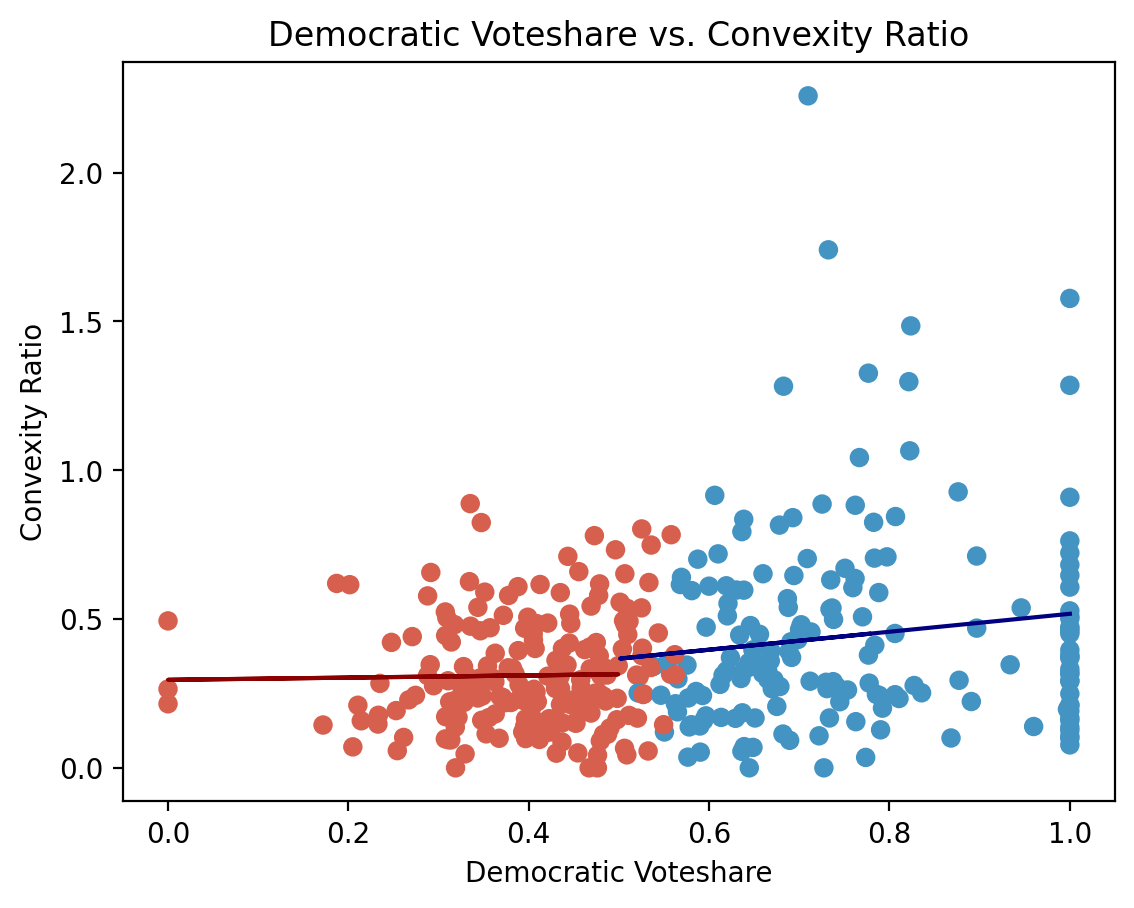

In [26]:
# regression line for democrat and republican majority districts
color_map = {"D": 0.8, "R": 0.2}
colors_D = dists_geo[dists_geo["Party"] == "D"]["Incumbent"].map(color_map)
colors_R = dists_geo[dists_geo["Party"] == "R"]["Incumbent"].map(color_map)


x_D = dists_geo[dists_geo["Party"] == "D"][["D Voteshare"]]
y_D = dists_geo[dists_geo["Party"] == "D"][["Ratio"]]
x_R = dists_geo[dists_geo["Party"] == "R"][["D Voteshare"]]
y_R = dists_geo[dists_geo["Party"] == "R"][["Ratio"]]

regressor_D = LinearRegression()
regressor_D.fit(x_D, y_D)
regressor_R = LinearRegression()
regressor_R.fit(x_R, y_R)

plt.scatter(x_D, 
            y_D, 
            c = colors_D, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_D, regressor_D.predict(x_D), color = 'navy')
plt.scatter(x_R, 
            y_R, 
            c = colors_R, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_R, regressor_R.predict(x_R), color = 'darkred')
plt.xlim(-0.05,1.05)
plt.title("Democratic Voteshare vs. Convexity Ratio")
plt.xlabel("Democratic Voteshare")
plt.ylabel("Convexity Ratio")
plt.show()

In [30]:
# difference between regression lines at d_voteshare = 0.5
point = [[0.5]]
regressor_D.predict(point)

/hpc/m3/python/3.11.11/data_science-2025.08.21/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[0.3667326]])

In [31]:
regressor_R.predict(point)

/hpc/m3/python/3.11.11/data_science-2025.08.21/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[0.31429191]])

Subsection b: diff in diff

In [ ]:
from diff_diff import DifferenceInDifferences

# Fit a basic DiD model
did = DifferenceInDifferences()
results = did.fit(data, outcome='y', treatment='treated', time='post')
print(results.summary())


did = DifferenceInDifferences()
did.fit(dists_geo, y="outcome", treatment="treatment", post="post")

# Display the summary table
print(did.summary())

<Axes: xlabel='dem_percs', ylabel='Ratio'>

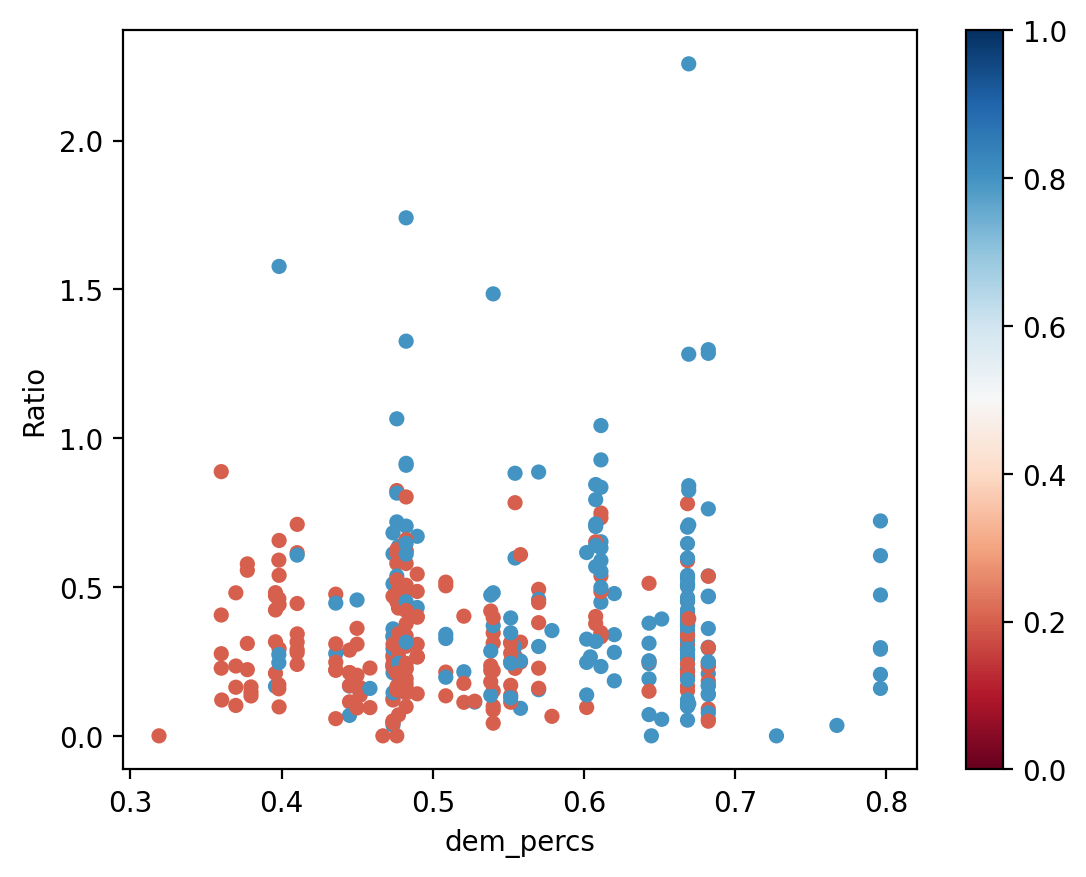

In [72]:
color_map = {"D": 0.8, "R": 0.2}
colors = dists_geo["Incumbent"].map(color_map)
dists_geo.plot.scatter(x = "dem_percs", 
                       y = "Ratio", 
                       c = colors, 
                       cmap = "RdBu",
                       vmin = 0,
                       vmax = 1)

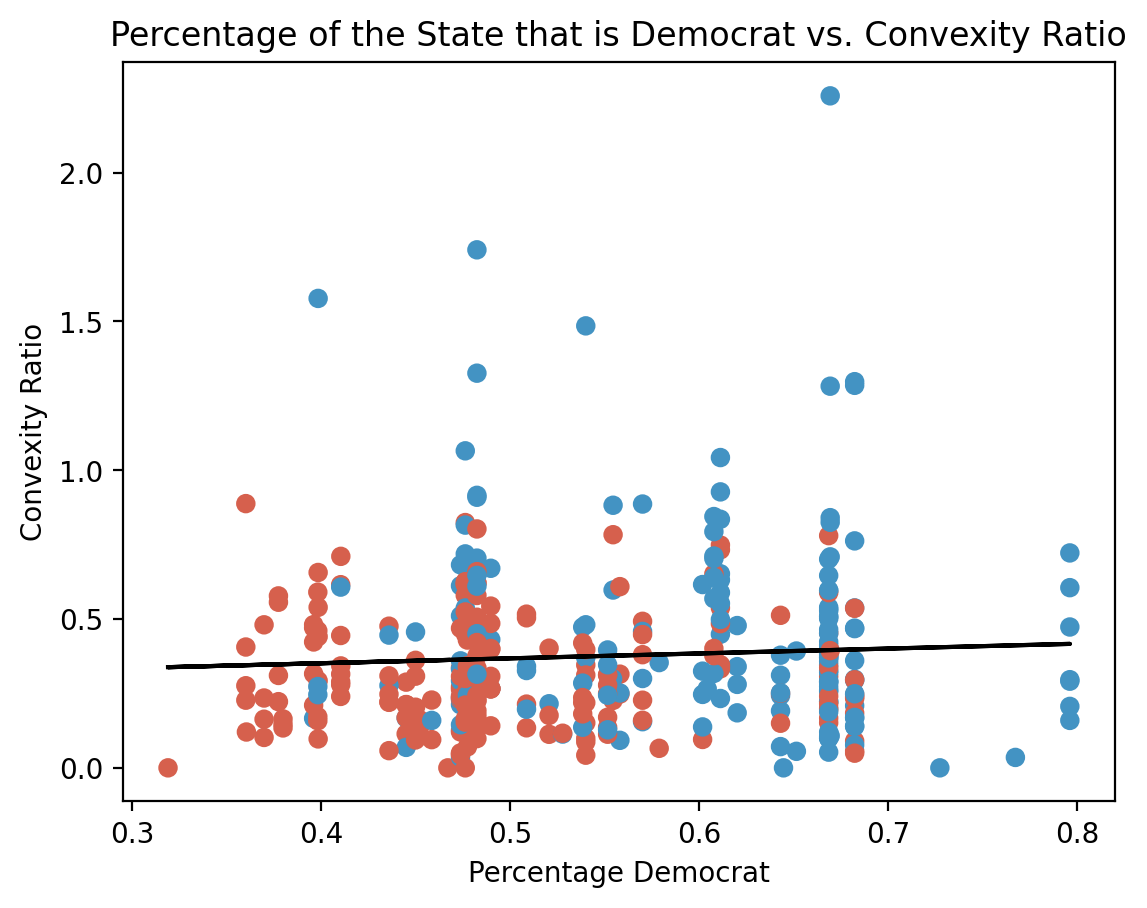

In [78]:
# single regression line for all data
color_map = {"D": 0.8, "R": 0.2}
colors = dists_geo["Incumbent"].map(color_map)

x = dists_geo[["dem_percs"]]
y = dists_geo[["Ratio"]]

regressor = LinearRegression()
regressor.fit(x, y)

plt.scatter(x, 
            y, 
            c = colors, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x, regressor.predict(x), color = 'black')
plt.title("Percentage of the State that is Democrat vs. Convexity Ratio")
plt.xlabel("Percentage Democrat")
plt.ylabel("Convexity Ratio")
plt.show()

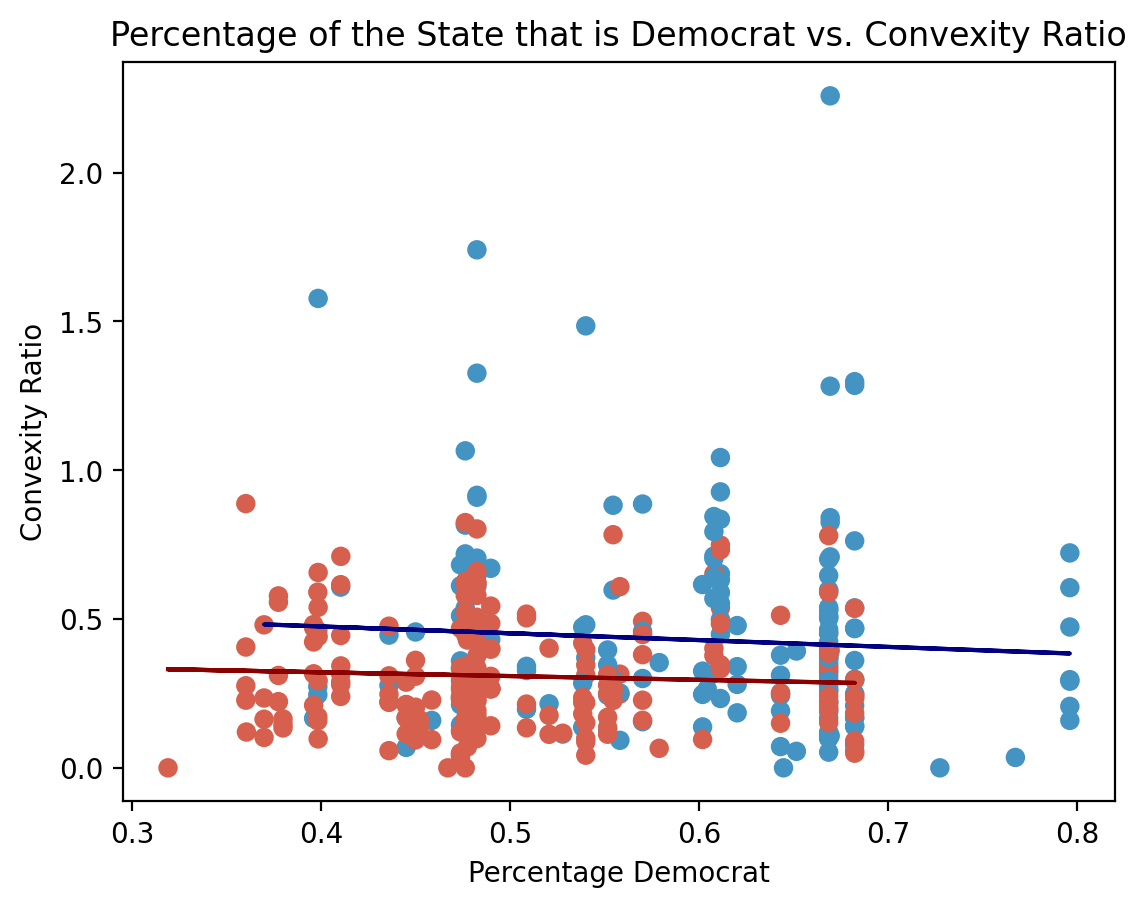

In [77]:
# regression line for democrat and republican majority districts
color_map = {"D": 0.8, "R": 0.2}
colors_D = dists_geo[dists_geo["Party"] == "D"]["Incumbent"].map(color_map)
colors_R = dists_geo[dists_geo["Party"] == "R"]["Incumbent"].map(color_map)


x_D = dists_geo[dists_geo["Party"] == "D"][["dem_percs"]]
y_D = dists_geo[dists_geo["Party"] == "D"][["Ratio"]]
x_R = dists_geo[dists_geo["Party"] == "R"][["dem_percs"]]
y_R = dists_geo[dists_geo["Party"] == "R"][["Ratio"]]

regressor_D = LinearRegression()
regressor_D.fit(x_D, y_D)
regressor_R = LinearRegression()
regressor_R.fit(x_R, y_R)

plt.scatter(x_D, 
            y_D, 
            c = colors_D, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_D, regressor_D.predict(x_D), color = 'navy')
plt.scatter(x_R, 
            y_R, 
            c = colors_R, 
            cmap = "RdBu",
            vmin = 0,
            vmax = 1)
plt.plot(x_R, regressor_R.predict(x_R), color = 'darkred')
#plt.xlim(-0.05,1.05)
plt.title("Percentage of the State that is Democrat vs. Convexity Ratio")
plt.xlabel("Percentage Democrat")
plt.ylabel("Convexity Ratio")
plt.show()

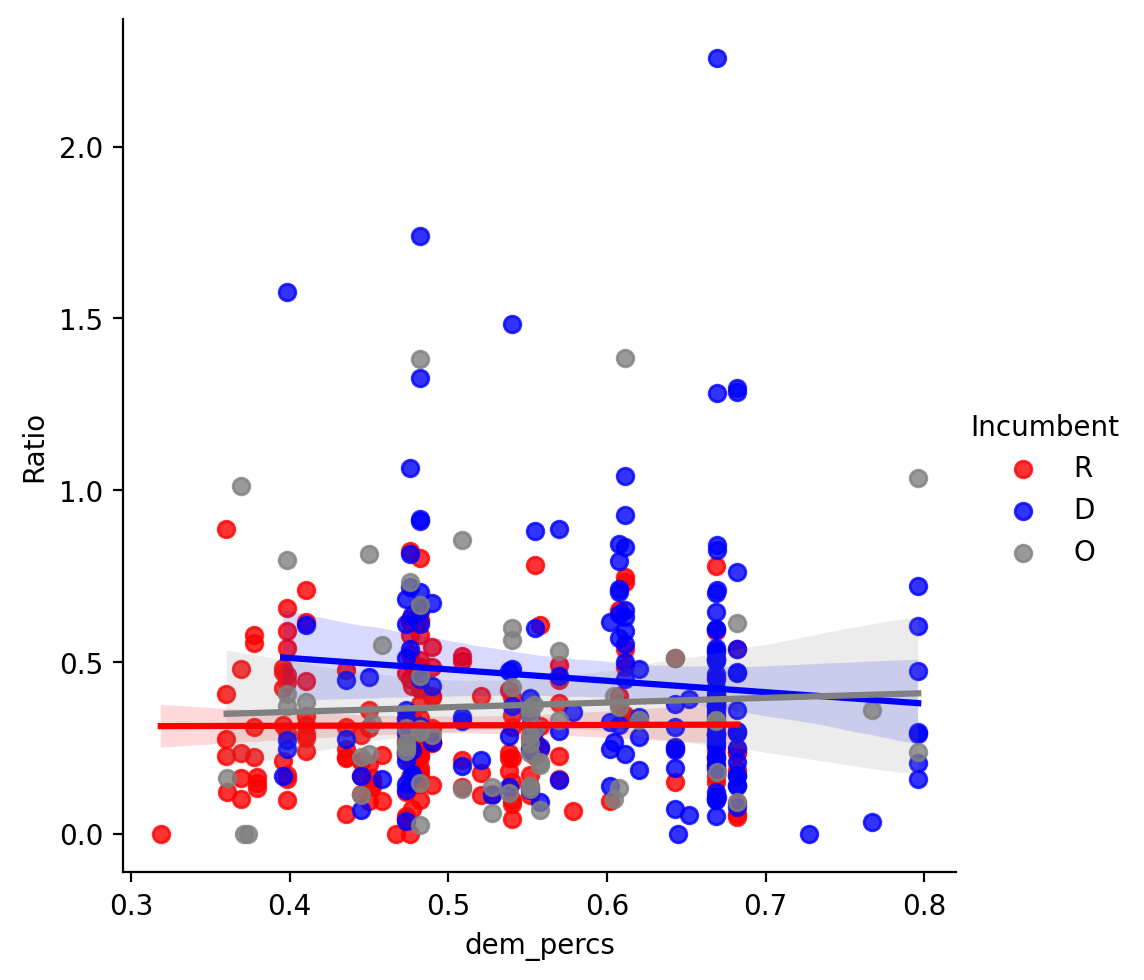

In [94]:
# adding confidence intervals
import seaborn as sns

color_map = {"D": 0.8, "R": 0.2}
colors = dists_geo["Incumbent"].map(color_map)

sns.lmplot(x = "dem_percs", 
            y = "Ratio", 
            data = dists_geo,
            ci = 95,
            hue = "Incumbent",
            palette = ["red", "blue", "grey"])
#sns.color_palette("RdBu", n_colors = 2)

In [96]:
dists_demo[dists_demo["Incumbent"] == "O"].head(10)

,Year,Dem Votes,GOP Votes,D Voteshare,Incumbent,Party,codes
15241,2018,161000.0,133083.0,0.5474644913170772,O,D,AZ2
15248,2018,159583.0,101662.0,0.6108557101571322,O,D,AZ9
15287,2018,126002.0,118391.0,0.5155712315819193,O,D,CA39
15297,2018,166453.0,128577.0,0.5641900823645053,O,D,CA49
15303,2018,259608.0,144901.0,0.6417854732527583,O,D,CO2
15313,2018,151225.0,119426.0,0.5587453953615542,O,D,CT5
15320,2018,145758.0,187891.0,0.4368602933022428,O,R,FL6
15329,2018,134132.0,151380.0,0.4697946145871277,O,R,FL15
15331,2018,117194.0,193326.0,0.37741208295761947,O,R,FL17
15341,2018,130743.0,115588.0,0.5307614551152717,O,D,FL27
